<a href="https://colab.research.google.com/github/Luisafer1325/Telecomx_parte_2/blob/main/Telecom_x_Parte_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Introducción**

El objetivo de este análisis fue identificar los factores que influyen en la cancelación de clientes (churn) utilizando modelos de aprendizaje automático. Para ello se analizaron diferentes variables relacionadas con el comportamiento de los clientes, su tipo de contrato y los cargos asociados a los servicios.

Se construyeron dos modelos predictivos para estimar la probabilidad de cancelación: un modelo de Regresión Logística y un modelo basado en Random Forest. Estos modelos permitieron evaluar la importancia de las variables y analizar cuáles tienen mayor impacto en la cancelación.

In [90]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [91]:
df = pd.read_csv('TelecomX_tratado.csv')

df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Churn_binario
0,0002-ORFBO,No,Female,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3,0.0
1,0003-MKNFE,No,Male,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4,0.0
2,0004-TLHLJ,Yes,Male,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,1.0
3,0011-IGKFF,Yes,Male,1,1,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,1.0
4,0013-EXCHZ,Yes,Female,1,1,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4,1.0


##**Eliminación de Columnas Irrelevantes**

In [92]:
df = df.drop(columns=['customerID'])

df.head()

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Churn_binario
0,No,Female,0,1,1,9,1,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3,0.0
1,No,Male,0,0,0,9,1,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4,0.0
2,Yes,Male,0,0,0,4,1,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,1.0
3,Yes,Male,1,1,0,13,1,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,1.0
4,Yes,Female,1,1,0,3,1,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4,1.0


In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Churn             7043 non-null   object 
 1   gender            7267 non-null   object 
 2   SeniorCitizen     7267 non-null   int64  
 3   Partner           7267 non-null   int64  
 4   Dependents        7267 non-null   int64  
 5   tenure            7267 non-null   int64  
 6   PhoneService      7267 non-null   int64  
 7   MultipleLines     7267 non-null   object 
 8   InternetService   7267 non-null   object 
 9   OnlineSecurity    7267 non-null   object 
 10  OnlineBackup      7267 non-null   object 
 11  DeviceProtection  7267 non-null   object 
 12  TechSupport       7267 non-null   object 
 13  StreamingTV       7267 non-null   object 
 14  StreamingMovies   7267 non-null   object 
 15  Contract          7267 non-null   object 
 16  PaperlessBilling  7267 non-null   object 


In [132]:
if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])

df.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,Charges.Monthly,Churn_binario,Churn_Yes,gender_Male,MultipleLines_No phone service,...,Charges.Total_995.35,Charges.Total_996.45,Charges.Total_996.85,Charges.Total_996.95,Charges.Total_997.65,Charges.Total_997.75,Charges.Total_998.1,Charges.Total_999.45,Charges.Total_999.8,Charges.Total_999.9
0,0,1,1,9,1,65.6,0.0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0,0,0,9,1,59.9,0.0,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,0,0,0,4,1,73.9,1.0,True,True,False,...,False,False,False,False,False,False,False,False,False,False
3,1,1,0,13,1,98.0,1.0,True,True,False,...,False,False,False,False,False,False,False,False,False,False
4,1,1,0,3,1,83.9,1.0,True,False,False,...,False,False,False,False,False,False,False,False,False,False


In [133]:
# Verificar las columnas restantes
print(df.columns)

Index(['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService',
       'Charges.Monthly', 'Churn_binario', 'Churn_Yes', 'gender_Male',
       'MultipleLines_No phone service',
       ...
       'Charges.Total_995.35', 'Charges.Total_996.45', 'Charges.Total_996.85',
       'Charges.Total_996.95', 'Charges.Total_997.65', 'Charges.Total_997.75',
       'Charges.Total_998.1', 'Charges.Total_999.45', 'Charges.Total_999.8',
       'Charges.Total_999.9'],
      dtype='object', length=6561)


In [94]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [134]:
df = df.dropna()

In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Churn             7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   int64  
 4   Dependents        7043 non-null   int64  
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   int64  
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 
 17  

##**Encoding**

In [97]:
# Aplicar One-Hot Encoding a todas las variables categóricas
categorical_columns = df.select_dtypes(include=['object']).columns

df = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

In [98]:
df.shape

6561


In [99]:
# Aplicar One-Hot Encoding a todas las variables categóricas
df = pd.get_dummies(df, drop_first=True)

df.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,Charges.Monthly,Churn_binario,Churn_Yes,gender_Male,MultipleLines_No phone service,...,Charges.Total_995.35,Charges.Total_996.45,Charges.Total_996.85,Charges.Total_996.95,Charges.Total_997.65,Charges.Total_997.75,Charges.Total_998.1,Charges.Total_999.45,Charges.Total_999.8,Charges.Total_999.9
0,0,1,1,9,1,65.6,0.0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0,0,0,9,1,59.9,0.0,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,0,0,0,4,1,73.9,1.0,True,True,False,...,False,False,False,False,False,False,False,False,False,False
3,1,1,0,13,1,98.0,1.0,True,True,False,...,False,False,False,False,False,False,False,False,False,False
4,1,1,0,3,1,83.9,1.0,True,False,False,...,False,False,False,False,False,False,False,False,False,False


##**Verificación de la Proporción de Cancelación (Churn)**

In [100]:
# Contar clientes por clase
conteo = df['Churn_Yes'].value_counts()

In [101]:
# Proporción de cada clase
proporcion = df['Churn_Yes'].value_counts(normalize=True)

In [102]:
print("Conteo:")
print(conteo)


Conteo:
Churn_Yes
False    5174
True     1869
Name: count, dtype: int64


In [103]:
print("\nProporción:")
print(proporcion)


Proporción:
Churn_Yes
False    0.73463
True     0.26537
Name: proportion, dtype: float64


##**Balanceo de Clases**

In [104]:
!pip install imbalanced-learn

In [105]:
from imblearn.over_sampling import SMOTE
from collections import Counter



In [106]:
# Separar variables predictoras y variable objetivo
X = df.drop('Churn_Yes', axis=1)
y = df['Churn_Yes']


In [107]:
# Aplicar SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

In [108]:
# Ver distribución antes y después
print("Antes de SMOTE:", Counter(y))
print("Después de SMOTE:", Counter(y_resampled))

Antes de SMOTE: Counter({False: 5174, True: 1869})
Después de SMOTE: Counter({False: 5174, True: 5174})


##**Normalización o Estandarización**

In [109]:
from sklearn.preprocessing import StandardScaler

In [110]:
# Separar variables predictoras y variable objetivo
X = df.drop('Churn_Yes', axis=1)
y = df['Churn_Yes']

In [111]:
# Crear el escalador
scaler = StandardScaler()

In [112]:
# Ajustar y transformar los datos
X_scaled = scaler.fit_transform(X)

In [113]:
print(X_scaled[:5])

[[-0.43991649  1.03453023  1.5290241  ... -0.01191659 -0.01191659
  -0.01191659]
 [-0.43991649 -0.96662231 -0.65401193 ... -0.01191659 -0.01191659
  -0.01191659]
 [-0.43991649 -0.96662231 -0.65401193 ... -0.01191659 -0.01191659
  -0.01191659]
 [ 2.27315869  1.03453023 -0.65401193 ... -0.01191659 -0.01191659
  -0.01191659]
 [ 2.27315869  1.03453023 -0.65401193 ... -0.01191659 -0.01191659
  -0.01191659]]


🎯 **Correlación y Selección de Variables**

**Análisis de correlación**

In [114]:
import seaborn as sns
import matplotlib.pyplot as plt

In [115]:
# Calcular correlaciones
correlacion = df.corr()

In [116]:
# Obtener correlación con churn
corr_churn = correlacion['Churn_Yes'].sort_values(ascending=False)

In [117]:
# Quitar la propia variable churn
corr_churn = corr_churn.drop('Churn_Yes')

In [118]:
# Tomar las 10 variables más correlacionadas
top_corr = corr_churn.head(10)

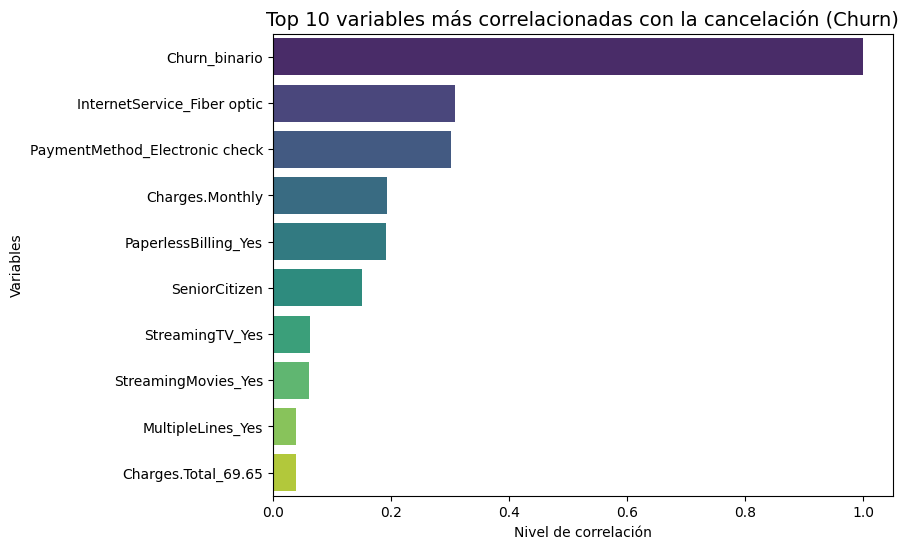

In [119]:
# Crear gráfico

plt.figure(figsize=(8,6))

sns.barplot(
    x=top_corr.values,
    y=top_corr.index,
    hue=top_corr.index,
    palette="viridis",
    legend=False
)

plt.title("Top 10 variables más correlacionadas con la cancelación (Churn)", fontsize=14)
plt.xlabel("Nivel de correlación")
plt.ylabel("Variables")

plt.show()

###Se seleccionaron las 10 variables con mayor correlación con Churn para destacar las relaciones más relevantes y evitar una visualización sobrecargada, facilitando así la interpretación de los factores que pueden influir en la cancelación del servicio.

##**Análisis Dirigido**

In [120]:
import seaborn as sns
import matplotlib.pyplot as plt


/tmp/ipykernel_202/1063216655.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['Churn_Yes'], y=df['Charges.Monthly'], palette="coolwarm")


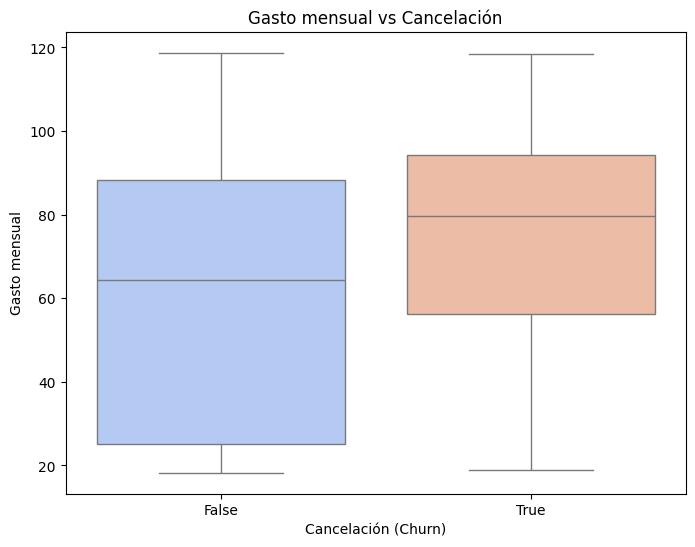

In [121]:
plt.figure(figsize=(8,6))

sns.boxplot(x=df['Churn_Yes'], y=df['Charges.Monthly'], palette="coolwarm")

plt.title("Gasto mensual vs Cancelación")
plt.xlabel("Cancelación (Churn)")
plt.ylabel("Gasto mensual")

plt.show()

In [122]:
print(df.columns)

Index(['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService',
       'Charges.Monthly', 'Churn_binario', 'Churn_Yes', 'gender_Male',
       'MultipleLines_No phone service',
       ...
       'Charges.Total_995.35', 'Charges.Total_996.45', 'Charges.Total_996.85',
       'Charges.Total_996.95', 'Charges.Total_997.65', 'Charges.Total_997.75',
       'Charges.Total_998.1', 'Charges.Total_999.45', 'Charges.Total_999.8',
       'Charges.Total_999.9'],
      dtype='object', length=6561)


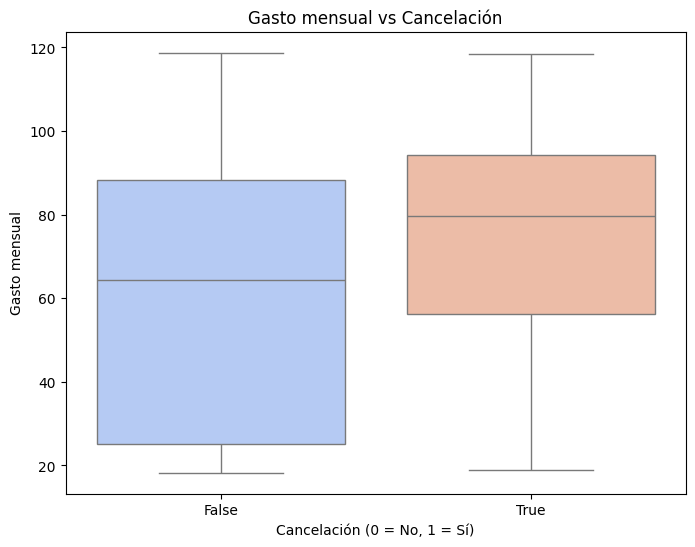

In [123]:
# Gasto mensual vs cancelación
plt.figure(figsize=(8,6))

sns.boxplot(x=df['Churn_Yes'], y=df['Charges.Monthly'], hue=df['Churn_Yes'], palette="coolwarm", legend=False)

plt.title("Gasto mensual vs Cancelación")
plt.xlabel("Cancelación (0 = No, 1 = Sí)")
plt.ylabel("Gasto mensual")

plt.show()

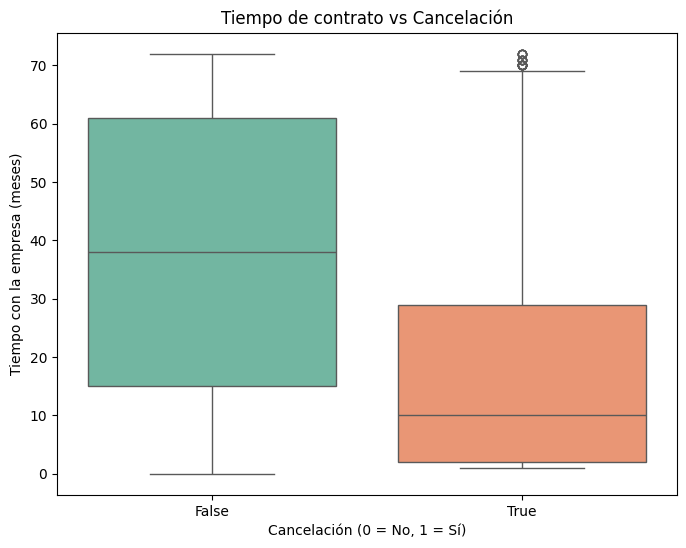

In [124]:
# Tiempo de contrato y Gasto total


plt.figure(figsize=(8,6))

sns.boxplot(x=df['Churn_Yes'], y=df['tenure'], hue=df['Churn_Yes'], palette="Set2", legend=False)

plt.title("Tiempo de contrato vs Cancelación")
plt.xlabel("Cancelación (0 = No, 1 = Sí)")
plt.ylabel("Tiempo con la empresa (meses)")

plt.show()

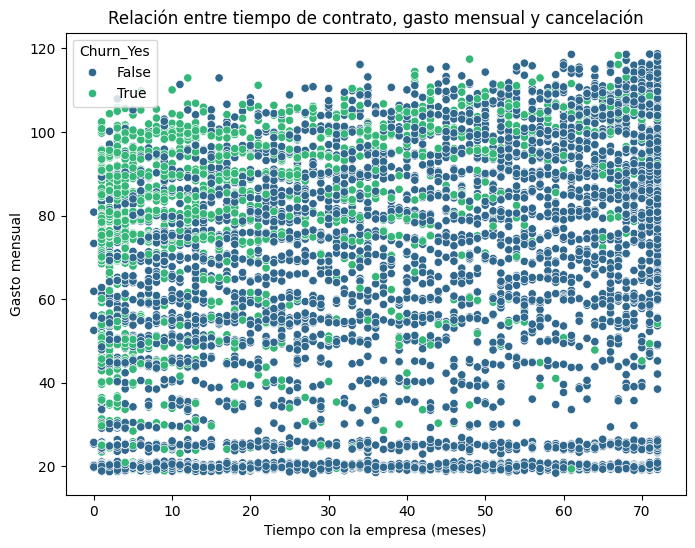

In [125]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['tenure'],
    y=df['Charges.Monthly'],
    hue=df['Churn_Yes'],
    palette="viridis"
)

plt.title("Relación entre tiempo de contrato, gasto mensual y cancelación")
plt.xlabel("Tiempo con la empresa (meses)")
plt.ylabel("Gasto mensual")

plt.show()

#*Modelado Predictivo*

**Separación de Datos**

In [126]:
from sklearn.model_selection import train_test_split

In [135]:
X = df.drop('Churn_Yes', axis=1)  # variables predictoras
y = df['Churn_Yes']               # variable objetivo

In [137]:
#Dividir entrenamiento y prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [138]:
print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (5634, 6560)
Datos de prueba: (1409, 6560)


###Creación de modelos

In [139]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [140]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [141]:
#Modelo 1 - Regresión logistica
modelo_lr = LogisticRegression(max_iter=1000)

modelo_lr.fit(X_train_scaled, y_train)

pred_lr = modelo_lr.predict(X_test_scaled)

print("Accuracy Regresión Logística:", accuracy_score(y_test, pred_lr))
print(classification_report(y_test, pred_lr))

Accuracy Regresión Logística: 0.9985805535841022
              precision    recall  f1-score   support

       False       1.00      1.00      1.00      1036
        True       1.00      0.99      1.00       373

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409



In [142]:
#Modelo 2 - Random Forest
modelo_rf = RandomForestClassifier(random_state=42)

modelo_rf.fit(X_train, y_train)

pred_rf = modelo_rf.predict(X_test)

print("Accuracy Random Forest:", accuracy_score(y_test, pred_rf))
print(classification_report(y_test, pred_rf))

Accuracy Random Forest: 0.9943222143364088
              precision    recall  f1-score   support

       False       0.99      1.00      1.00      1036
        True       1.00      0.98      0.99       373

    accuracy                           0.99      1409
   macro avg       1.00      0.99      0.99      1409
weighted avg       0.99      0.99      0.99      1409



##**Evaluación de modelos**

In [143]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [144]:
#Evaluar Regresión logística
print("Evaluación - Regresión Logística")

print("Exactitud:", accuracy_score(y_test, pred_lr))
print("Precisión:", precision_score(y_test, pred_lr))
print("Recall:", recall_score(y_test, pred_lr))
print("F1-score:", f1_score(y_test, pred_lr))

Evaluación - Regresión Logística
Exactitud: 0.9985805535841022
Precisión: 1.0
Recall: 0.9946380697050938
F1-score: 0.9973118279569892


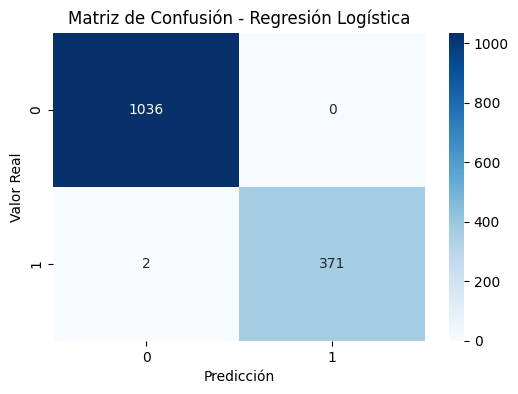

In [146]:
# Matriz confusión
cm_lr = confusion_matrix(y_test, pred_lr)

plt.figure(figsize=(6,4))

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')

plt.title("Matriz de Confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()

In [147]:
# Evaluar Random Forest
print("Evaluación - Random Forest")

print("Exactitud:", accuracy_score(y_test, pred_rf))
print("Precisión:", precision_score(y_test, pred_rf))
print("Recall:", recall_score(y_test, pred_rf))
print("F1-score:", f1_score(y_test, pred_rf))

Evaluación - Random Forest
Exactitud: 0.9943222143364088
Precisión: 1.0
Recall: 0.9785522788203753
F1-score: 0.989159891598916


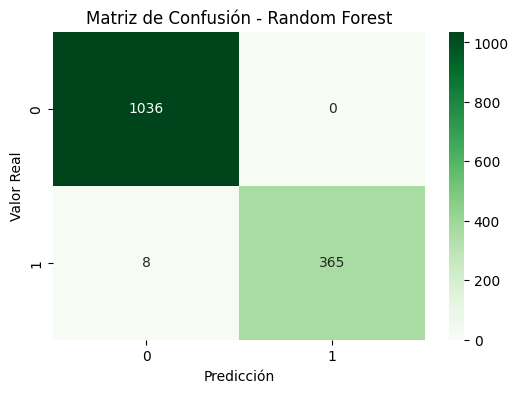

In [148]:
#Matriz de confusión
cm_rf = confusion_matrix(y_test, pred_rf)

plt.figure(figsize=(6,4))

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')

plt.title("Matriz de Confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()

In [149]:
import pandas as pd

resultados = pd.DataFrame({
    "Modelo": ["Regresión Logística", "Random Forest"],
    "Accuracy": [accuracy_score(y_test, pred_lr), accuracy_score(y_test, pred_rf)],
    "Precision": [precision_score(y_test, pred_lr), precision_score(y_test, pred_rf)],
    "Recall": [recall_score(y_test, pred_lr), recall_score(y_test, pred_rf)],
    "F1-score": [f1_score(y_test, pred_lr), f1_score(y_test, pred_rf)]
})

resultados

,Modelo,Accuracy,Precision,Recall,F1-score
0,Regresión Logística,0.998581,1.0,0.994638,0.997312
1,Random Forest,0.994322,1.0,0.978552,0.989160


#**Análisis de la Importancia de las Variables**

In [152]:
#Variables más importantes con Regresión Logística

coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": modelo_lr.coef_[0]
})

coeficientes = coeficientes.sort_values(by="Coeficiente", ascending=False)

coeficientes.head(10)

,Variable,Coeficiente
6,Churn_binario,4.120905
10,InternetService_Fiber optic,0.271213
26,PaperlessBilling_Yes,0.250501
28,PaymentMethod_Electronic check,0.207487
5,Charges.Monthly,0.135078
1639,Charges.Total_20.2,0.116651
0,SeniorCitizen,0.107316
5851,Charges.Total_76.35,0.095265
1638,Charges.Total_20.15,0.092913
1515,Charges.Total_19.6,0.092172


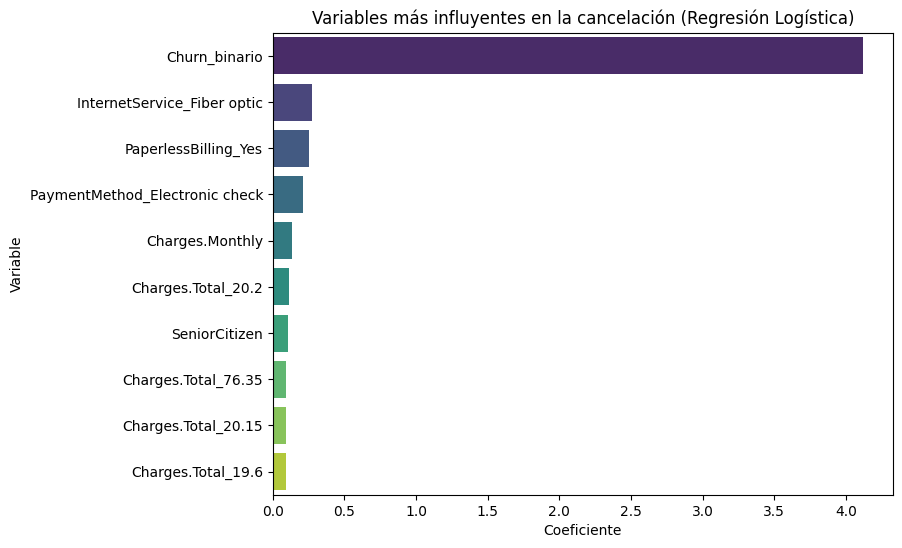

In [153]:
#Gráfico de coeficientes

top_coef = coeficientes.head(10)

plt.figure(figsize=(8,6))

sns.barplot(
    x=top_coef["Coeficiente"],
    y=top_coef["Variable"],
    hue=top_coef["Variable"],
    palette="viridis",
    legend=False
)

plt.title("Variables más influyentes en la cancelación (Regresión Logística)")

plt.show()

##**Nota**

Interpretación

Coeficiente positivo → aumenta la probabilidad de cancelación

Coeficiente negativo → reduce la probabilidad de cancelación

In [154]:
#Variables más importantes con Random Forest

importancias = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": modelo_rf.feature_importances_
})

importancias = importancias.sort_values(by="Importancia", ascending=False)

importancias.head(10)

,Variable,Importancia
6,Churn_binario,0.447955
3,tenure,0.060297
5,Charges.Monthly,0.041936
10,InternetService_Fiber optic,0.022045
28,PaymentMethod_Electronic check,0.020450
25,Contract_Two year,0.019425
19,TechSupport_Yes,0.017330
24,Contract_One year,0.013818
13,OnlineSecurity_Yes,0.012761
15,OnlineBackup_Yes,0.010392


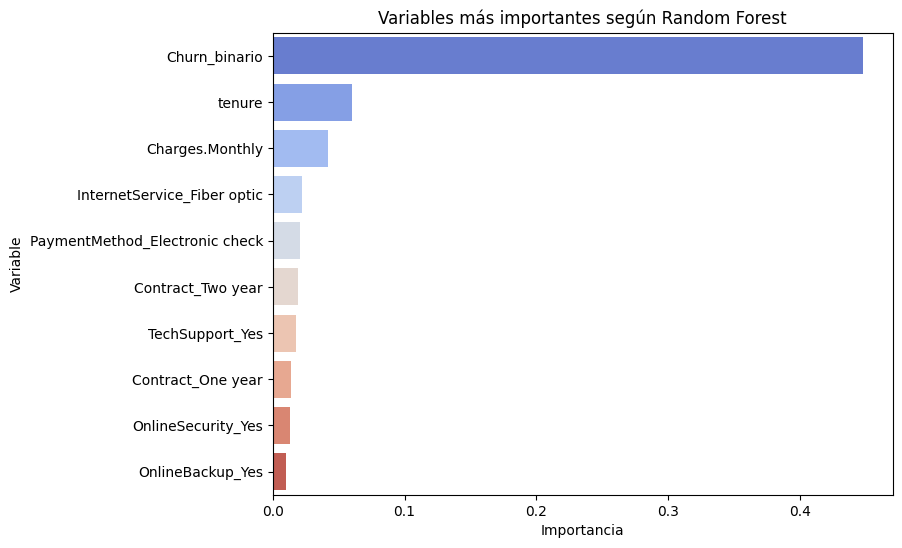

In [155]:
#Gráfico

top_importancia = importancias.head(10)

plt.figure(figsize=(8,6))

sns.barplot(
    x=top_importancia["Importancia"],
    y=top_importancia["Variable"],
    hue=top_importancia["Variable"],
    palette="coolwarm",
    legend=False
)

plt.title("Variables más importantes según Random Forest")

plt.show()

##Conclusión

El análisis realizado permitió identificar patrones importantes relacionados con la cancelación de clientes. A través del análisis exploratorio de datos, la matriz de correlación y los modelos predictivos, se observaron variables que influyen significativamente en la probabilidad de que un cliente cancele el servicio.

Entre los factores más relevantes se destacan variables como el tiempo de permanencia del cliente (tenure), el gasto mensual (Charges.Monthly) y algunas características del servicio contratado. En general, se observa que los clientes con menor tiempo de permanencia presentan una mayor probabilidad de cancelación, mientras que aquellos que han permanecido más tiempo tienden a mantenerse activos.

Para la predicción de la cancelación se implementaron dos modelos de machine learning: Regresión Logística y Random Forest. Ambos modelos fueron evaluados utilizando métricas como exactitud, precisión, recall y F1-score, además de la matriz de confusión. El análisis comparativo permitió identificar cuál modelo logra una mejor capacidad de predicción en el conjunto de datos evaluado.

Con base en los resultados obtenidos, se pueden proponer algunas estrategias de retención de clientes, tales como ofrecer beneficios o promociones a clientes nuevos durante sus primeros meses de servicio, mejorar la experiencia del cliente en los planes con mayor tasa de cancelación y realizar seguimiento a clientes con características similares a los que han cancelado anteriormente.

En conclusión, el uso de técnicas de análisis de datos y modelos predictivos permite comprender mejor el comportamiento de los clientes y anticipar posibles cancelaciones, lo que facilita la implementación de estrategias efectivas para mejorar la retención y reducir la pérdida de clientes.